In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
import sys
sys.path.append('..')
from firstpassage.FPTCalculator import *
from lo_circuit.fusion_network import *
from lo_circuit.fusion_order import *
from graphtheory.ghz_partitioning import *
import random
import perceval as pcvl
import itertools
import networkx as nx

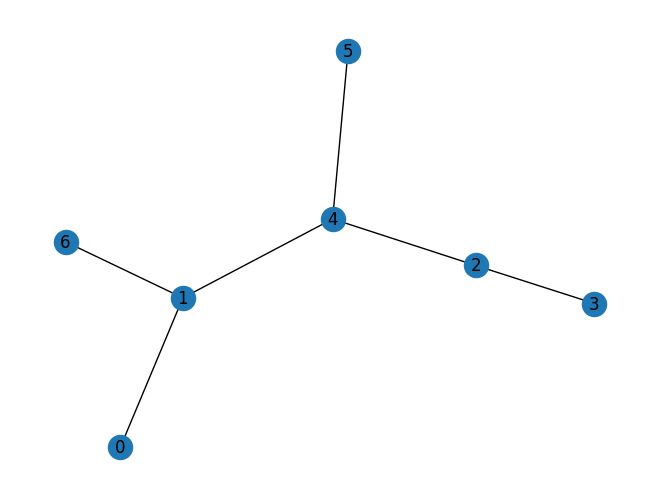

In [11]:
G = nx.Graph([(0, 1), (1, 4), (1, 6), (2, 3), (2, 4), (4, 5)])
nx.draw(G, with_labels=True)

In [12]:
G.edges

EdgeView([(0, 1), (1, 4), (1, 6), (4, 2), (4, 5), (2, 3)])

In [13]:
success_probs = [0.5,0.66,0.75,0.85,1]
# names = [('dfs', 'random', True), ('dfs', 'random', False),('dfs', 'min', True),('dfs', 'min', False),('dfs', 'max', True),('dfs', 'max', False),('bfs', 'random', True),('bfs', 'random', False),('bfs', 'min', True),('bfs', 'min', False),('bfs', 'max', True),('bfs', 'max', False)]
names = [('dfs', 'random'),('dfs', 'min'),('dfs', 'max'),('bfs', 'random'),('bfs', 'min'),('bfs', 'max'),('rand')]
strategy_improvement = {name: {p: [] for p in success_probs} for name in names}
fpt_bins = {p: [] for p in success_probs}
for conf in itertools.product(['dfs','bfs'],['random','min','max']): #
    T = get_spanning_tree(G,conf[0],conf[1],False)
    max_deg_vertex = sorted([(G.degree(v),v) for v in G.nodes])[-1][1]
    fusion_network = build_fusion_network_from_spanning_tree(T,max_deg_vertex,G)
    fusion_order = approximate_minimal_fpt_fusion_order(fusion_network)
    print("tree fusion_order",fusion_order)
    max_qubit = int(max([q for f in fusion_order for q in f])/3)*3+3
    fpt = get_fp_times(fusion_order, max_qubit, success_probs)
    print("fpt",fpt)
    for k,v in fpt.items():
        fpt_bins[k].append(v)

#random
fusion_network_rand = build_fusion_network_random(G)
fusion_order = approximate_minimal_fpt_fusion_order(fusion_network_rand)
print("random fusion_order",fusion_order)
max_qubit = int(max([q for f in fusion_order for q in f])/3)*3+3
fpt = get_fp_times(fusion_order, max_qubit, success_probs)
print("random fpt",fpt)
for k,v in fpt.items():
    fpt_bins[k].append(v)

tree fusion_order [(1, 12), (4, 6), (2, 9), (0, 3)]
fpt {0.5: 16.00000002177595, 0.66: 8.804296422679753, 0.75: 6.81481481628968, 0.85: 5.365357233673611, 1: 4.000000002281529}
tree fusion_order [(1, 12), (4, 6), (2, 9), (0, 3)]
fpt {0.5: 16.00000002177595, 0.66: 8.804296422679753, 0.75: 6.81481481628968, 0.85: 5.365357233673611, 1: 4.000000002281529}
tree fusion_order [(1, 12), (4, 6), (2, 9), (0, 3)]
fpt {0.5: 16.00000002177595, 0.66: 8.804296422679753, 0.75: 6.81481481628968, 0.85: 5.365357233673611, 1: 4.000000002281529}
tree fusion_order [(1, 12), (4, 6), (2, 9), (0, 3)]
fpt {0.5: 16.00000002177595, 0.66: 8.804296422679753, 0.75: 6.81481481628968, 0.85: 5.365357233673611, 1: 4.000000002281529}
tree fusion_order [(1, 12), (4, 6), (2, 9), (0, 3)]
fpt {0.5: 16.00000002177595, 0.66: 8.804296422679753, 0.75: 6.81481481628968, 0.85: 5.365357233673611, 1: 4.000000002281529}
tree fusion_order [(1, 12), (4, 6), (2, 9), (0, 3)]
fpt {0.5: 16.00000002177595, 0.66: 8.804296422679753, 0.75: 6.8

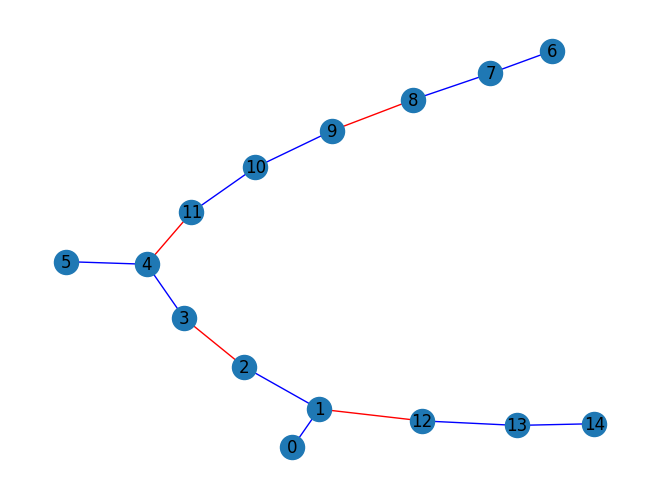

In [14]:
draw_fusion_network([(8, 9), (1, 12), (4, 11), (2, 3)])

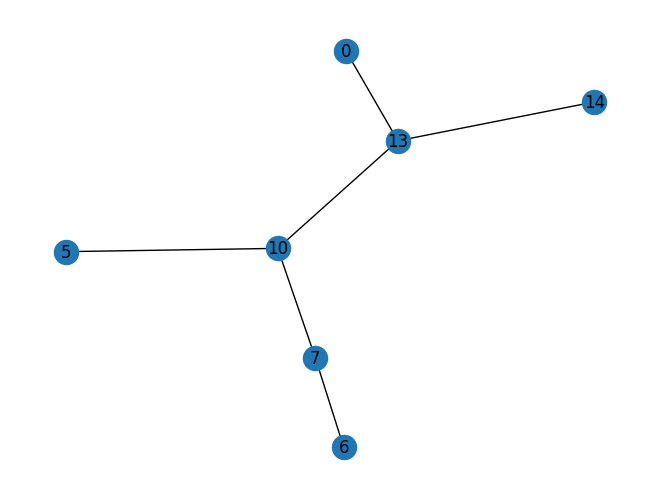

In [15]:
draw_contracted_fusion_network([(8, 9), (1, 12), (4, 11), (2, 3)])

In [ ]:
#wierd bug: 
# [(0, 1), (2, 3), (4, 5), (1, 4), (2, 4), (1, 6)] not working

# [(2, 4), (1, 6), (0, 1), (1, 4), (4, 5), (2, 3)] working

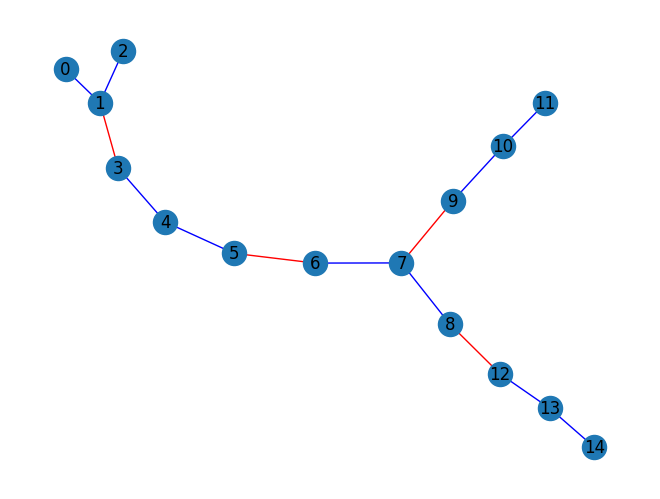

In [6]:
fusion_network_rand = build_fusion_network_random(G)
fusion_order = approximate_minimal_fpt_fusion_order(fusion_network_rand)
draw_fusion_network(fusion_order)

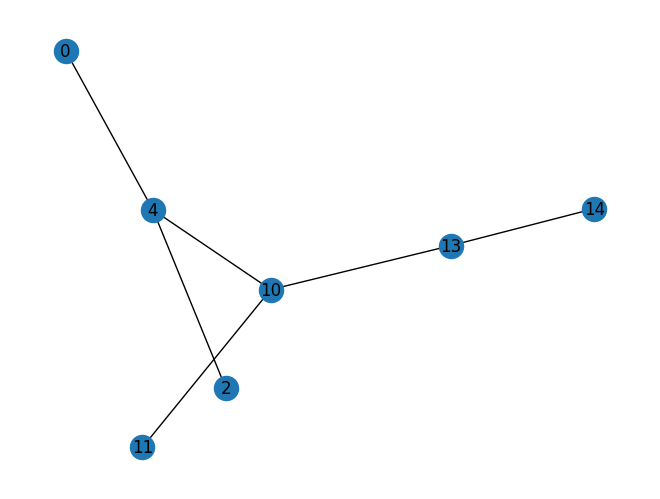

In [7]:
draw_contracted_fusion_network(fusion_order)

In [8]:
fusion_order

[(1, 3), (8, 12), (7, 9), (5, 6)]